## Import Packages

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon
from shapely.geometry import Polygon
from shapely.strtree import STRtree
from sklearn.cluster import DBSCAN
from tqdm.notebook import tqdm

In [3]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
# from gridsample.mapping.plot import create_interactive_map

## Set Global Params

### Folder Paths

In [4]:
LOCATION = "Betul"

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "01 Processed Data"
)
OUTPUT_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "02 Outputs" / "v1"
)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

### Code Parameters

In [6]:
INDIA_PROJECTED_CRS = "24378"

In [7]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

## Custom Functions

In [8]:
def clean_non_polygons(gdf):
    """
    Clean Geometry Collections and MultiPolygons by keeping only Polygons inside
    and dropping points or lines etc.
    """

    def _clean_geom(geom):
        if geom is None:
            return Polygon()

        # If it's already a Polygon, return as is
        if geom.geom_type == "Polygon":
            return geom

        # Get polygons from MultiPolygon or GeometryCollection
        polygons = []
        if hasattr(geom, "geoms"):
            for g in geom.geoms:
                if g.geom_type == "Polygon":
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return Polygon()
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and set invalid geometries to None
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf

In [9]:
def difference_overlay_without_discard(gdf1, gdf2):
    overlay_gdf = gpd.overlay(
        gdf1.reset_index(names="original_index"),
        gdf2,
        how="difference",
        keep_geom_type=True,
    )

    # Create a copy to modify
    gdf1_v2 = gdf1.copy()
    # By default, set all geometries to an empty Polygon
    gdf1_v2["geometry"] = Polygon()
    # Update the geometries for the rows that still exist after the overlay
    gdf1_v2.loc[overlay_gdf["original_index"], "geometry"] = overlay_gdf.geometry.values

    gdf1_v2 = clean_non_polygons(gdf1_v2)

    return gdf1_v2

In [10]:
# for TIFF files
import rasterio
from rasterio.features import shapes
from rasterio.plot import show
from shapely.geometry import shape


def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [11]:
def build_optimised_distance_matrix(gdf, max_distance_considered, n_jobs=-1):
    """
    Build an optimized distance matrix for the given GeoDataFrame.

    Parameters
    ----------
    gdf : GeoDataFrame
        The input GeoDataFrame.
    max_distance_considered : float
        The maximum distance to consider for clustering.
    n_jobs : int, optional
        The number of jobs to run in parallel (default is -1, which uses all available cores).

    Returns
    -------
    np.ndarray
        The optimized distance matrix.
    """
    # Prepare geoms and build a spatial index (STRtree) for fast neighbor queries
    geometries = gdf.geometry.values
    n = len(geometries)
    tree = STRtree(geometries)

    # Prepare distance calculator
    def _get_distances_for_geom(i, geom, geometries, tree, max_distance_considered):
        """Calculates distances for a single geometry to its neighbors."""
        distances = []
        # Query the STRtree to find potential neighbors within the buffer
        candidate_indices = tree.query(geom.buffer(max_distance_considered))
        for j in candidate_indices:
            if i == j:
                continue
            geom_candidate = geometries[j]
            d = geom.distance(geom_candidate)
            distances.append((i, j, d))
        return distances

    # Run the distance calculation in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(_get_distances_for_geom)(
            i, geom, geometries, tree, max_distance_considered
        )
        for i, geom in enumerate(tqdm(geometries, desc="Building distance matrix"))
    )

    # Initialize full matrix with initial value too high to be considered by DBSCAN when clustering
    distance_matrix = np.full((n, n), 99999)
    # Populate the distance matrix
    for res_list in results:
        for i, j, d in res_list:
            distance_matrix[i, j] = d

    # Set diagonal to zero for self-distances
    np.fill_diagonal(distance_matrix, 0)

    return distance_matrix

In [12]:
def format_DBSCAN_cluster_labels(
    gdf_with_stats_and_cluster_id: gpd.GeoDataFrame,
    cluster_id_col: str,
    distance_threshold: int | None = None,
    area_col: str = "Usable Area (ha)",
):
    # filter to only clustered rows
    clustered_rows_df = gdf_with_stats_and_cluster_id[
        gdf_with_stats_and_cluster_id[cluster_id_col] != -1
    ]

    # get cluster labels with sizes
    cluster_labels_with_sizes_df = (
        clustered_rows_df.groupby(cluster_id_col)[area_col].sum()
    ).reset_index()

    # sort cluster labels by size
    ordered_cluster_labels_df = cluster_labels_with_sizes_df.sort_values(
        by=area_col, ascending=False
    )

    # add labels starting from largest size as parcel 1 and so on
    if distance_threshold:
        ordered_cluster_labels_df["formatted_ids"] = create_ids(
            df_length=len(ordered_cluster_labels_df),
            prefix=f"PARCEL_{distance_threshold}m_",
        )
        cluster_mapping = {-1: f"PARCEL_{distance_threshold}m_UNCLUSTERED"}
    else:
        ordered_cluster_labels_df["formatted_ids"] = create_ids(
            df_length=len(ordered_cluster_labels_df), prefix="PARCEL_"
        )
        cluster_mapping = {-1: "PARCEL_UNCLUSTERED"}
    cluster_mapping.update(
        dict(
            zip(
                ordered_cluster_labels_df[cluster_id_col],
                ordered_cluster_labels_df["formatted_ids"],
            )
        )
    )

    # reassign formatted_ids in the original GeoDataFrame with the new values
    gdf_with_stats_and_cluster_id[cluster_id_col] = gdf_with_stats_and_cluster_id[
        cluster_id_col
    ].map(cluster_mapping)

    return gdf_with_stats_and_cluster_id

## Load cleaned khasras

In [14]:
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
betul_gdf = gpd.read_parquet(
    PROCESSED_DATA_DIR / "Cleaned Khasras" / "betul_cleaned_khasras.parquet"
)
betul_gdf

,Khasra ID (Unique),Patch Name,Khasra ID,Original Area (ha),geometry
202,121 (BZU1),BZU1,121,0.432744,"POLYGON ((77.70990 21.36144, 77.70994 21.36145..."
207,122 (BZU1),BZU1,122,0.817783,"POLYGON ((77.70925 21.36088, 77.70928 21.36082..."
220,124 (BZU1),BZU1,124,2.080606,"POLYGON ((77.71153 21.35842, 77.71158 21.35847..."
222,125 (BZU1),BZU1,125,0.454494,"POLYGON ((77.71602 21.36030, 77.71595 21.36031..."
237,128 (BZU1),BZU1,128,46.905774,"POLYGON ((77.71592 21.36032, 77.71583 21.36032..."
...,...,...,...,...,...
827,23 (BZU959),BZU959,23,0.186204,"MULTIPOLYGON (((77.62905 21.70015, 77.62883 21..."
94,109 (BZU982),BZU982,109,0.080666,"POLYGON ((77.59548 21.71178, 77.59645 21.71155..."
2276,89 (BZU982),BZU982,89,7.851117,"POLYGON ((77.59329 21.70557, 77.59305 21.70558..."
2312,92 (BZU982),BZU982,92,2.242117,"POLYGON ((77.59352 21.71108, 77.59345 21.71110..."


In [16]:
gdf_4326 = betul_gdf
gdf = betul_gdf.to_crs(INDIA_PROJECTED_CRS)

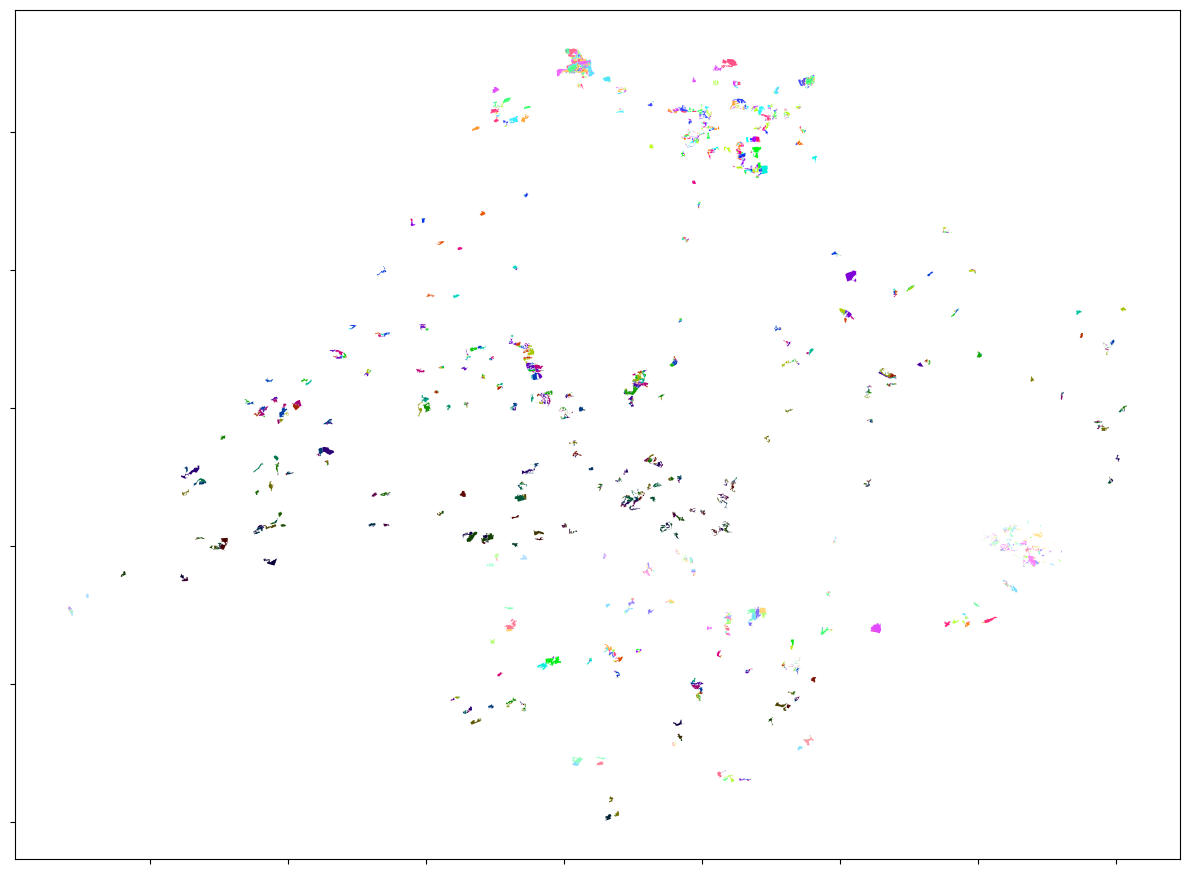

In [17]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [18]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [19]:
from gridsample.utils_rooftop import (
    download_VIDA_rooftops_data_by_s2,
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
)

#### Identify S2 cell IDs

In [20]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 4
Unique S2 cell IDs: [4311915168230539264, 4311352218277117952, 4142467232250724352, 4143030182204145664]


/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


#### Check if identified cells cover all areas of interest


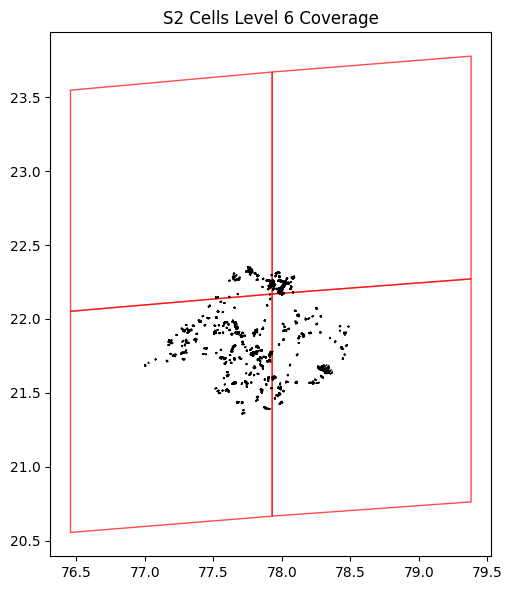

0.0 square degrees area not covered by an S2 cell


In [21]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [22]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

File 4311915168230539264 already exists.
File 4311352218277117952 already exists.
File 4142467232250724352 already exists.
File 4143030182204145664 already exists.


#### Load and process rooftop data

In [24]:
try:
    print("Checking for existing filtered rooftops...")
    subset_rooftops_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Rooftops" / "rooftops.parquet"
    )
    print("Loaded existing filtered rooftops.")
except FileNotFoundError:
    print("No saved filtered rooftops found, processing raw data...")
    rooftop_gdf_list = []
    for s2_cell_id in s2_cell_ids:
        s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
        rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
        rooftop_gdf_list.append(rooftop_gdf)

    rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
    rooftop_gdf = rooftop_gdf[
        [
            "bf_source",
            "confidence",
            "area_in_meters",
            "geometry",
        ]
    ]

    rooftop_gdf["rooftop_id"] = create_ids(
        len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_"
    )
    rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

    # Filter to only rooftops that overlap the parcels
    subset_rooftops_gdf = rooftop_gdf.sjoin(
        gdf, how="inner", predicate="intersects"
    ).drop(columns=["index_right"])
    subset_rooftops_gdf.drop(columns=gdf.columns.drop("geometry"), inplace=True)

    save_shapefiles(
        subset_rooftops_gdf,
        PROCESSED_DATA_DIR / "Filtered Rooftops",
        "rooftops",
        formats=["parquet"],
    )

Checking for existing filtered rooftops...
No saved filtered rooftops found, processing raw data...


In [25]:
buffer = 10
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(buffered_rooftops_gdf, gdf, how="intersection")

#### Settlements

Try different thresholds

In [26]:
# for eps in [200, 250, 300]:
#     clusterer = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
#     building_centroids = buildings_overlap_gdf.geometry.centroid
#     X = np.array(list(zip(building_centroids.x, building_centroids.y)))
#     building_cluster_ids = clusterer.fit_predict(X)
#     buildings_overlap_gdf["settlement_id"] = building_cluster_ids

#     settlement_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] != -1
#     ]
#     isolated_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] == -1
#     ]

#     # get the convex hull of each cluster
#     settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
#     settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
#     settlements_gdf.geometry = settlements_gdf.convex_hull

#     # get cutout of the buffered building shapes that overlap parcels
#     settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
#     settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

#     # plot
#     ax = gdf.plot(figsize=(20, 20))
#     settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
#     settlement_buildings_gdf.plot(ax=ax, color="red")
#     isolated_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

#     # add stats
#     total_count = len(buildings_overlap_gdf)
#     settlement_count = len(settlement_buildings_gdf)
#     perc_settlement_buildings = settlement_count / total_count * 100
#     isolated_count = len(isolated_buildings_gdf)
#     total_area = buildings_overlap_gdf.area.sum() / 10_000
#     settlement_area = settlements_gdf.area.sum() / 10_000
#     title = f"""
#     Buildings at {eps}m eps
#     Total Buildings: {total_count}
#     Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
#     Total Building Area (ha): {total_area:.2f}
#     Settlement Area (ha): {settlement_area:.2f}
#     """
#     ax.set_title(title, fontsize=12)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     plt.savefig(
#         DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
#     )

Run for the chosen threshold

In [27]:
CHOSEN_EPS = 10
MIN_BUILDINGS = 5
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=MIN_BUILDINGS, n_jobs=-1)

building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)

buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
isolated_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_59822/3450254654.py:24: UserWarning: `keep_geom_type=True` in overlay resulted in 9 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")


In [28]:
building_counts_df = (
    buildings_overlap_gdf.groupby("Khasra ID (Unique)")
    .size()
    .reset_index(name="Building Count")
)
building_counts_df

,Khasra ID (Unique),Building Count
0,1 (BZU1252),4
1,1 (BZU2552),28
2,1 (BZU4005),2
3,1 (BZU4090),2
4,1 (BZU4091),147
...,...,...
826,99 (BZU1912),2
827,99 (BZU2359),3
828,99 (BZU2956),1
829,99 (BZU3574),19


In [29]:
isolated_buildings_overlap_gdf = isolated_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [30]:
isolated_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = (
    isolated_buildings_overlap_gdf.area / 10_000
)
isolated_buildings_unusable_area_df = isolated_buildings_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Isolated Buildings (ha)"]
]

In [31]:
settlements_overlap_gdf = settlements_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = (
    settlements_overlap_gdf.area / 10_000
)
settlements_unusable_area_df = settlements_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Settlements (ha)"]
]

### Landcover (Cropland, Water)

#### Landcover

In [32]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

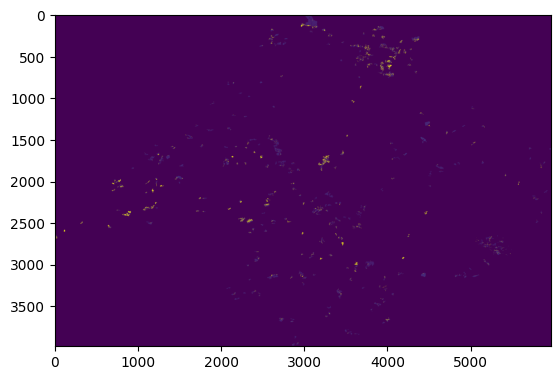

<Axes: >

In [33]:
masked_landcover_data, masked_transform = rasterio.mask.mask(
    src, [gdf_4326.unary_union], crop=True
)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [34]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [35]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [36]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(cropland_shapes_gdf, gdf, how="intersection")
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [37]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = (
    cropland_overlap_gdf.area / 10_000
)
cropland_unusable_area_df = cropland_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Cropland (ha)"]
]

#### Water

In [38]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [39]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(water_shapes_gdf, gdf, how="intersection")
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [40]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Water (ha)"]
]

#### Trees (not used right now)

In [41]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [42]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(tree_shapes_gdf, gdf, how="intersection")
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [43]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Tree Cover (ha)"]
]
tree_unusable_area_df

,Khasra ID (Unique),Unusable Area - Tree Cover (ha)
0,1 (BZU124),0.139385
1,1 (BZU1252),0.591086
2,1 (BZU1897),0.072020
3,1 (BZU2552),8.618076
4,1 (BZU3602),0.073464
...,...,...
663,97 (BZU1363),0.280504
664,98/1 (BZU3880),0.310368
665,99 (BZU1912),0.052116
666,99 (BZU2359),0.124506


### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [44]:
from utils import get_steep_shapes, get_steep_shapes_other

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pydem/dem_processing.py:76: RuntimeWarning: Cython functions are not compiled. UCA cannot be calculated. Consider compiling cython functions using: python setup.py build_ext --inplace
  warnings.warn("Cython functions are not compiled. UCA cannot be calculated."


In [45]:
# input the bounds below in the website and download all tiles that overlap it
gdf_4326.total_bounds

array([76.99764615, 21.35692976, 78.48922342, 22.35215663])

#### North and > 7deg

In [46]:
try:
    print("Checking for existing slope overlaps...")
    slope_overlap_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / "slopes.parquet"
    )
except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")
    dem_filenames = [
        "P5_PAN_CD_N21_000_E077_000_DEM_30m",
        "P5_PAN_CD_N21_000_E078_000_DEM_30m",
        "P5_PAN_CD_N22_000_E077_000_DEM_30m",
        "P5_PAN_CD_N22_000_E078_000_DEM_30m",
    ]

    steep_shapes_gdf_list = []
    for dem_filename in dem_filenames:
        dem_folderpath = RAW_DATA_DIR / "elevation"
        steep_shapes_gdf = get_steep_shapes(
            dem_folderpath=dem_folderpath,
            dem_filename=dem_filename,
            projected_crs=INDIA_PROJECTED_CRS,
            plot=False,
        )
        steep_shapes_gdf_list.append(steep_shapes_gdf)

    slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

    slope_overlap_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_gdf = slope_overlap_gdf.dissolve(
        by="Khasra ID (Unique)"
    ).reset_index()

    save_shapefiles(
        slope_overlap_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        "slopes",
        formats=["parquet"],
    )

Checking for existing slope overlaps...
No saved slope overlaps found, processing raw data...
Processing P5_PAN_CD_N21_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...
Processing P5_PAN_CD_N21_000_E078_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...
Processing P5_PAN_CD_N22_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...
Processing P5_PAN_CD_N22_000_E078_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...


In [47]:
slope_overlap_gdf["Unusable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Slope (ha)"]
]

<Axes: >

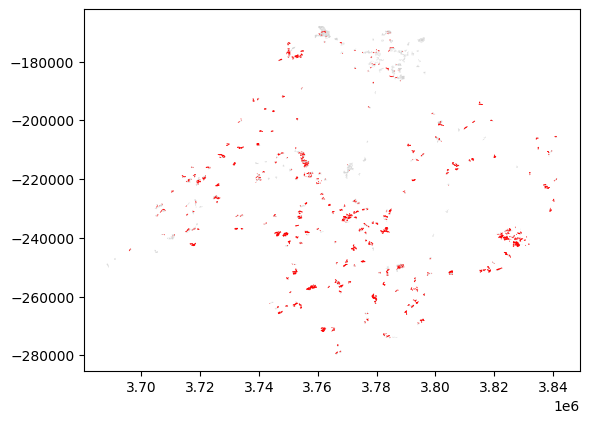

In [48]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

#### South and > 10deg

In [49]:
try:
    print("Checking for existing slope overlaps...")
    slope_overlap_other_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / "slopes_other.parquet"
    )
except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")
    dem_filenames = [
        "P5_PAN_CD_N21_000_E077_000_DEM_30m",
        "P5_PAN_CD_N21_000_E078_000_DEM_30m",
        "P5_PAN_CD_N22_000_E077_000_DEM_30m",
        "P5_PAN_CD_N22_000_E078_000_DEM_30m",
    ]

    steep_shapes_other_gdf_list = []
    for dem_filename in dem_filenames:
        dem_folderpath = RAW_DATA_DIR / "elevation"
        steep_shapes_other_gdf = get_steep_shapes_other(
            dem_folderpath=dem_folderpath,
            dem_filename=dem_filename,
            projected_crs=INDIA_PROJECTED_CRS,
            plot=False,
        )
        steep_shapes_other_gdf_list.append(steep_shapes_other_gdf)

    slope_shapes_other_gdf = pd.concat(steep_shapes_other_gdf_list, ignore_index=True)

    slope_overlap_other_gdf = gpd.overlay(
        slope_shapes_other_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_other_gdf = slope_overlap_other_gdf.dissolve(
        by="Khasra ID (Unique)"
    ).reset_index()

    save_shapefiles(
        slope_overlap_other_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        "slopes_other",
        formats=["parquet"],
    )

Checking for existing slope overlaps...
No saved slope overlaps found, processing raw data...
Processing P5_PAN_CD_N21_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...
Processing P5_PAN_CD_N21_000_E078_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...
Processing P5_PAN_CD_N22_000_E077_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...
Processing P5_PAN_CD_N22_000_E078_000_DEM_30m...
No 'ELLIPSOID' key in wkt: list index out of range
Trying to load pre-calculated slopes and aspects...
Extracting vector shapes...


<Axes: >

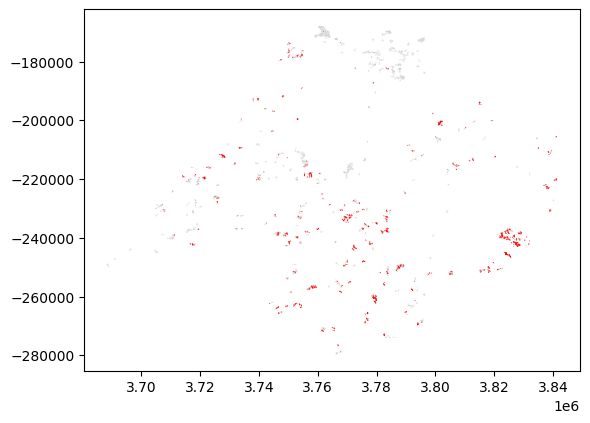

In [50]:
ax = gdf.plot(color="lightgrey")
slope_overlap_other_gdf.buffer(100).plot(ax=ax, color="red")

In [51]:
slope_overlap_other_gdf["Unusable Area - Slope South 10deg (ha)"] = slope_overlap_other_gdf.area / 10_000
slope_unusable_area_other_df = slope_overlap_other_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Slope South 10deg (ha)"]
]

## Save individual layers to file

In [52]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Water (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# isolated buildings
save_shapefiles(
    isolated_buildings_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "isolated_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Slope (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

# slopes other
save_shapefiles(
    slope_overlap_other_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Slope South 10deg (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes_other",
    formats=["kml"],
)

## Merge in unusable layers

### Plots

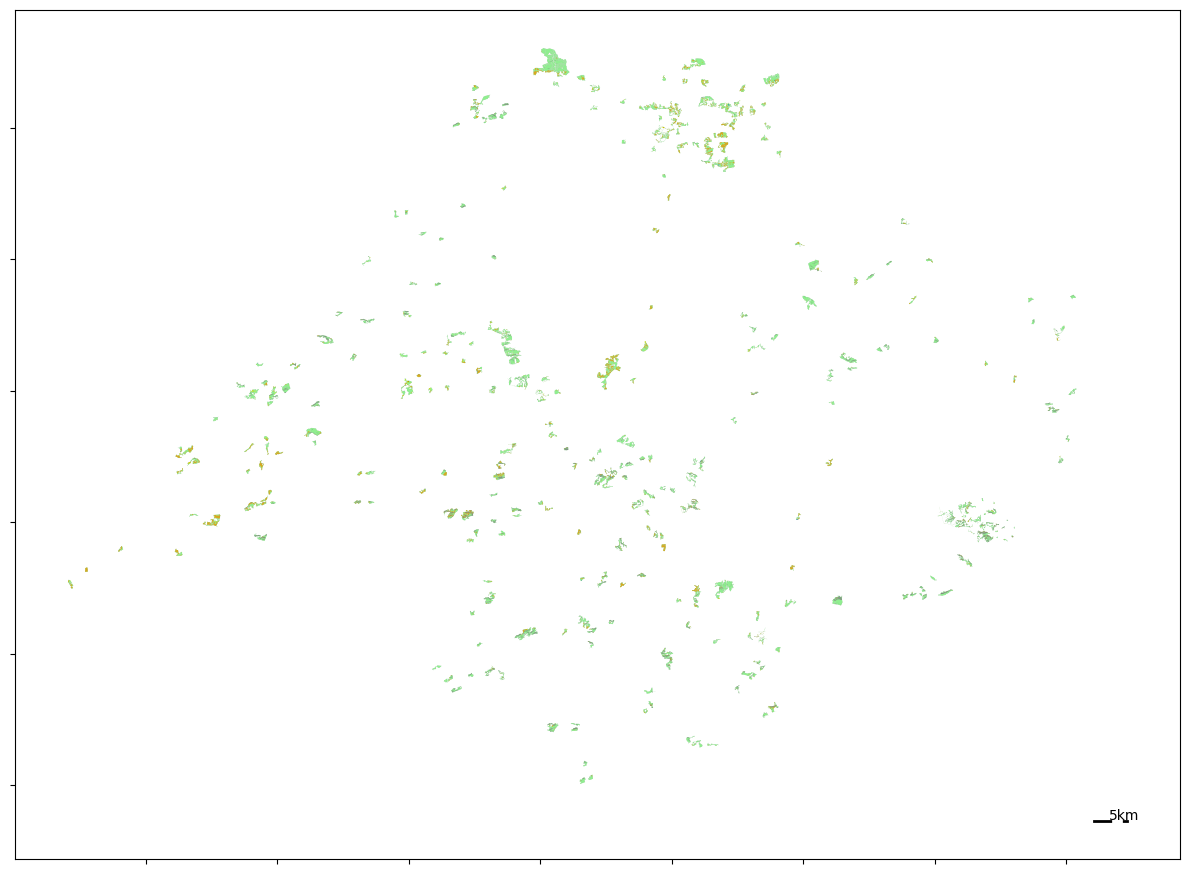

In [53]:
# add colored outline based on Name

ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
gdf.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf.plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")
settlements_overlap_gdf.plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")
water_overlap_gdf.plot(ax=ax, color=WATER_COLOR, label="Water")
cropland_overlap_gdf.plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")
slope_overlap_gdf.plot(ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg")
slope_overlap_other_gdf.plot(ax=ax, color=SLOPE_COLOR, alpha=0.5, label="Slopes South > 10 deg")

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

### Calculate Areas

##### Cut out unusable

In [77]:
# Make a copy of the original boundaries gdf and:
# 1. trim away its geometries based on the layers
# 2. add area stats
available_gdf = gdf.copy()

In [78]:
available_gdf["Original Area (ha)"] = available_gdf["geometry"].area / 10_000

In [79]:
# cut out water
available_gdf = difference_overlay_without_discard(
    available_gdf,
    water_overlap_gdf,
)
# cut out settlements
available_gdf = difference_overlay_without_discard(
    available_gdf,
    settlements_overlap_gdf,
)
# cut out slopes north
available_gdf = difference_overlay_without_discard(
    available_gdf,
    slope_overlap_gdf,
)
# cut out slopes south
available_gdf = difference_overlay_without_discard(
    available_gdf,
    slope_overlap_other_gdf,
)

In [80]:
available_gdf["Usable Area (ha)"] = available_gdf.area / 10_000
available_gdf["Unusable Area (ha)"] = (
    available_gdf["Original Area (ha)"] - available_gdf["Usable Area (ha)"]
)

# percentages
available_gdf["Usable Area (%)"] = (
    available_gdf["Usable Area (ha)"] / available_gdf["Original Area (ha)"] * 100
)
available_gdf["Unusable Area (%)"] = (
    available_gdf["Unusable Area (ha)"] / available_gdf["Original Area (ha)"] * 100
)

In [81]:
# # Final values (noiyat-adjusted)
# available_gdf["Final Usable Area (ha)"] = available_gdf["Usable Area (ha)"] * (
#     1 - available_gdf["Noiyat Unusable Area (%)"] / 100
# )
# available_gdf["Final Usable Area (%)"] = available_gdf["Usable Area (%)"] * (
#     1 - available_gdf["Noiyat Unusable Area (%)"] / 100
# )

In [82]:
save_shapefiles(
    available_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [83]:
# cut out cropland
available_gdf = difference_overlay_without_discard(
    available_gdf,
    cropland_overlap_gdf,
)

# cut out isolated buildings
available_gdf = difference_overlay_without_discard(
    available_gdf,
    isolated_buildings_overlap_gdf,
)

In [84]:
available_gdf["Usable and Available Area (ha)"] = available_gdf.area / 10_000
available_gdf["Usable but Unavailable Area (ha)"] = (
    available_gdf["Usable Area (ha)"] - available_gdf["Usable and Available Area (ha)"]
)

# percentages
available_gdf["Usable and Available Area (%)"] = (
    available_gdf["Usable and Available Area (ha)"]
    / available_gdf["Original Area (ha)"]
    * 100
)
available_gdf["Usable but Unavailable Area (%)"] = (
    available_gdf["Usable but Unavailable Area (ha)"]
    / available_gdf["Original Area (ha)"]
    * 100
)

In [85]:
# # Final values
# available_gdf["Final Usable and Available Area (ha)"] = available_gdf[
#     "Usable and Available Area (ha)"
# ] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)
# available_gdf["Final Usable and Available Area (%)"] = available_gdf[
#     "Usable and Available Area (%)"
# ] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)

In [86]:
# add unusable areas

all_unusable_area_cols_df = settlements_unusable_area_df.merge(
    water_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    slope_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    slope_unusable_area_other_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    cropland_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    isolated_buildings_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    building_counts_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)

# add onto the output and fill in null values with zeros (layer cols that don't overlap a given khasra will have null)
available_gdf = available_gdf.merge(
    all_unusable_area_cols_df, on="Khasra ID (Unique)", how="left"
)
available_gdf[all_unusable_area_cols_df.columns] = available_gdf[
    all_unusable_area_cols_df.columns
].fillna(0)

In [87]:
save_shapefiles(
    available_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "csv", "kml"],
)

## Save per-patch statistics (aggregation function is here)

In [88]:
# we want to have the stats and the original shapes (so the convex hull makes sense),
# so take a copy of the available_gdf
original_gdf_with_stats = available_gdf.copy()
# but replace the geometries with the original untrimmed geometries based on Khasra ID (Unique)
original_gdf_with_stats = original_gdf_with_stats.set_index("Khasra ID (Unique)")
original_gdf_with_stats["geometry"] = gdf.set_index("Khasra ID (Unique)")["geometry"]
original_gdf_with_stats = original_gdf_with_stats.reset_index()
print("Empty geometries:", original_gdf_with_stats["geometry"].is_empty.sum())

Empty geometries: 0


In [89]:
# CHECK
# ax = original_gdf_with_stats[original_gdf_with_stats["Khasra ID (Unique)"] == "124 (BWI3802)"].plot(color="red")
# available_gdf[available_gdf["Khasra ID (Unique)"] == "124 (BWI3802)"].plot(ax=ax)
# gdf[gdf["Khasra ID (Unique)"] == "124 (BWI3802)"].plot(ax=ax, color="black", alpha=1)

In [90]:
def get_aggregate_gdf(areas_gdf: gpd.GeoDataFrame, cluster_id_col: str):
    pivot_df = (
        areas_gdf.drop(
            columns=[
                "Khasra ID (Unique)",
                "Khasra ID (Unique)",
                # "Tehsil Name",
                # "Village Name",
                # "BHU Code",
                # "Noiyat",
                # "ROR KID",
                # "Noiyat Unusable Area (%)",
                # "Final Usable Area (%)",
                # "Final Usable and Available Area (%)",
                "Unusable Area (%)",
                "Usable Area (%)",
                "Usable and Available Area (%)",
                "Usable but Unavailable Area (%)",
                "geometry",
            ]
        )
        .groupby(cluster_id_col)
        .sum()
        .round(2)
    )
    # make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
    count_filtered_khasra_gdf = areas_gdf.groupby(cluster_id_col).agg(
        khasra_count=("Khasra ID (Unique)", "size"),
        khasra_names=("Khasra ID (Unique)", lambda x: ", ".join(list(x))),
    )
    count_filtered_khasra_gdf.rename(
        columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra ID (Unique)"},
        inplace=True,
    )
    # combine
    pivot_df = pivot_df.merge(
        count_filtered_khasra_gdf, on=cluster_id_col
    ).reset_index()

    # calculate % columns again

    # # Noiyat layers
    # pivot_df["Noiyat Unusable Area (%)"] = (
    #     pivot_df["Noiyat Unusable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    # ).round(2)
    # # set max to 100 and min to 0 for any weird values
    # pivot_df["Noiyat Unusable Area (%)"] = pivot_df["Noiyat Unusable Area (%)"].clip(
    #     0, 100
    # )

    # # Adjusted layers
    # pivot_df["Final Usable Area (%)"] = (
    #     pivot_df["Final Usable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    # ).round(2)
    # pivot_df["Final Usable and Available Area (%)"] = (
    #     pivot_df["Final Usable and Available Area (ha)"]
    #     / pivot_df["Original Area (ha)"]
    #     * 100
    # ).round(2)
    
    # IDi layers
    pivot_df["Unusable Area (%)"] = (
        pivot_df["Unusable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Usable Area (%)"] = (
        pivot_df["Usable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Usable and Available Area (%)"] = (
        pivot_df["Usable and Available Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)
    pivot_df["Usable but Unavailable Area (%)"] = (
        pivot_df["Usable but Unavailable Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)

    pivot_df = pivot_df[
        [
            # id
            cluster_id_col,
            "Khasra Count",
            "Khasra ID (Unique)",
            # original area
            "Original Area (ha)",
            # # Final areas
            # "Final Usable Area (ha)",
            # "Final Usable Area (%)",
            # "Final Usable and Available Area (ha)",
            # "Final Usable and Available Area (%)",
            # # noiyat
            # "Noiyat Unusable Area (ha)",
            # "Noiyat Unusable Area (%)",
            # layered areas
            "Usable Area (ha)",
            "Usable and Available Area (ha)",
            "Usable but Unavailable Area (ha)",
            "Unusable Area (ha)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "Unusable Area (%)",
            "Unusable Area - Settlements (ha)",
            "Unusable Area - Water (ha)",
            "Unusable Area - Slope (ha)",
            "Unusable Area - Slope South 10deg (ha)",
            "Unavailable Area - Cropland (ha)",
            "Unavailable Area - Isolated Buildings (ha)",
            # "Unusable Area - Dense Trees (ha)",
            "Building Count",
        ]
    ]

    # add the convex hull geometry
    convex_hull_geoms_gdf = (
        areas_gdf.dissolve(by=cluster_id_col)
        .convex_hull.to_frame(name="geometry")
        .reset_index()
    )
    pivot_df_with_geoms = pivot_df.merge(convex_hull_geoms_gdf, on=cluster_id_col)
    pivot_gdf = gpd.GeoDataFrame(pivot_df_with_geoms, geometry="geometry")

    return pivot_gdf

In [91]:
patch_gdf = get_aggregate_gdf(
    areas_gdf=original_gdf_with_stats, cluster_id_col="Patch Name"
)

In [92]:
save_shapefiles(
    patch_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Patch Shapefiles",
    "Patches",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 50.689999999999998.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 52.520000000000003.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 33.119999999999997.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Patches.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 24.100000000000001.
  ogr

## Cluster

### Create the distance matrix (based on boundary-to-boundary distances)

In [93]:
MAX_DISTANCE_CONSIDERED = 100

In [94]:
try:
    print("Trying to load saved distance matrix...")
    distance_matrix = np.load(PROCESSED_DATA_DIR / "distance_matrix.npy")
    print("Loaded saved distance matrix.")
except FileNotFoundError:
    print("No saved distance matrix found, building now...")
    # NOTE: took 42mins for ~16,000 rows
    distance_matrix = build_optimised_distance_matrix(
        gdf=original_gdf_with_stats,
        max_distance_considered=MAX_DISTANCE_CONSIDERED,
        n_jobs=1,
    )
    # save the numpy matrix to file
    np.save(PROCESSED_DATA_DIR / "distance_matrix.npy", distance_matrix)

Trying to load saved distance matrix...
No saved distance matrix found, building now...


Building distance matrix:   0%|          | 0/2375 [00:00<?, ?it/s]

### Clustering

In [95]:
gdf_with_cluster_id = original_gdf_with_stats.copy()
distance_threshold = 25
cluster_id_col = "Parcel ID"

In [96]:
db = DBSCAN(eps=distance_threshold, min_samples=2, metric="precomputed")
labels = db.fit_predict(distance_matrix)
gdf_with_cluster_id[cluster_id_col] = labels
gdf_with_cluster_id = format_DBSCAN_cluster_labels(
    gdf_with_stats_and_cluster_id=gdf_with_cluster_id,
    cluster_id_col=cluster_id_col,
    area_col="Usable Area (ha)",
)

<Axes: >

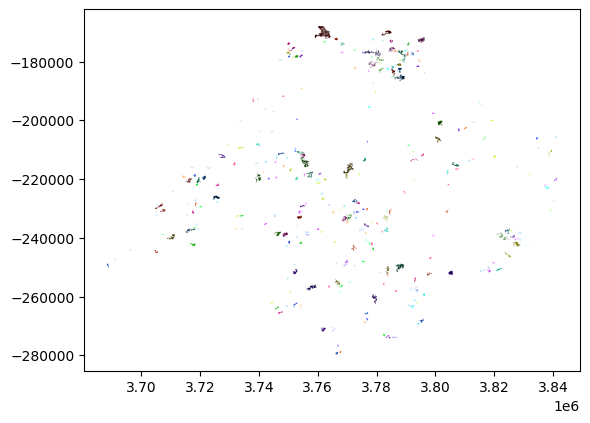

In [97]:
gdf_with_cluster_id.plot(
    column=cluster_id_col,
    cmap=ListedColormap(
        generate_colormap(len(gdf_with_cluster_id[cluster_id_col].unique()))
    ),
)

In [98]:
gdf_with_cluster_id = gdf_with_cluster_id[
    [
        "Parcel ID",
        "Khasra ID",
        # "Tehsil Code",
        # "Village Name",
        # "BHU Code",
        # "Patch Name",
        # "Noiyat",
        # "ROR KID",
        "Khasra ID (Unique)",
        "Original Area (ha)",
        # "Final Usable Area (ha)",
        # "Final Usable Area (%)",
        # "Final Usable and Available Area (ha)",
        # "Final Usable and Available Area (%)",
        # "Noiyat Unusable Area (ha)",
        # "Noiyat Unusable Area (%)",
        "Usable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Unusable Area (%)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unusable Area - Water (ha)",
        "Unusable Area - Slope (ha)",
        "Unusable Area - Slope South 10deg (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Building Count",
        "geometry",
    ]
]

In [99]:
save_shapefiles(
    gdf_with_cluster_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available_with_parcel_ids",
    formats=["parquet", "csv", "kml"],
)

### Group parcels as per discussion

In [ ]:
# groups = gpd.read_file(PROCESSED_DATA_DIR / "barwani_grouping.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
# temp_gdf = gdf_with_cluster_id.sjoin(groups, how="inner", predicate="intersects")

DataSourceError: ../data/01_processed/Solar Parks/Betul/01 Processed Data/barwani_grouping.kml: No such file or directory

<Axes: >

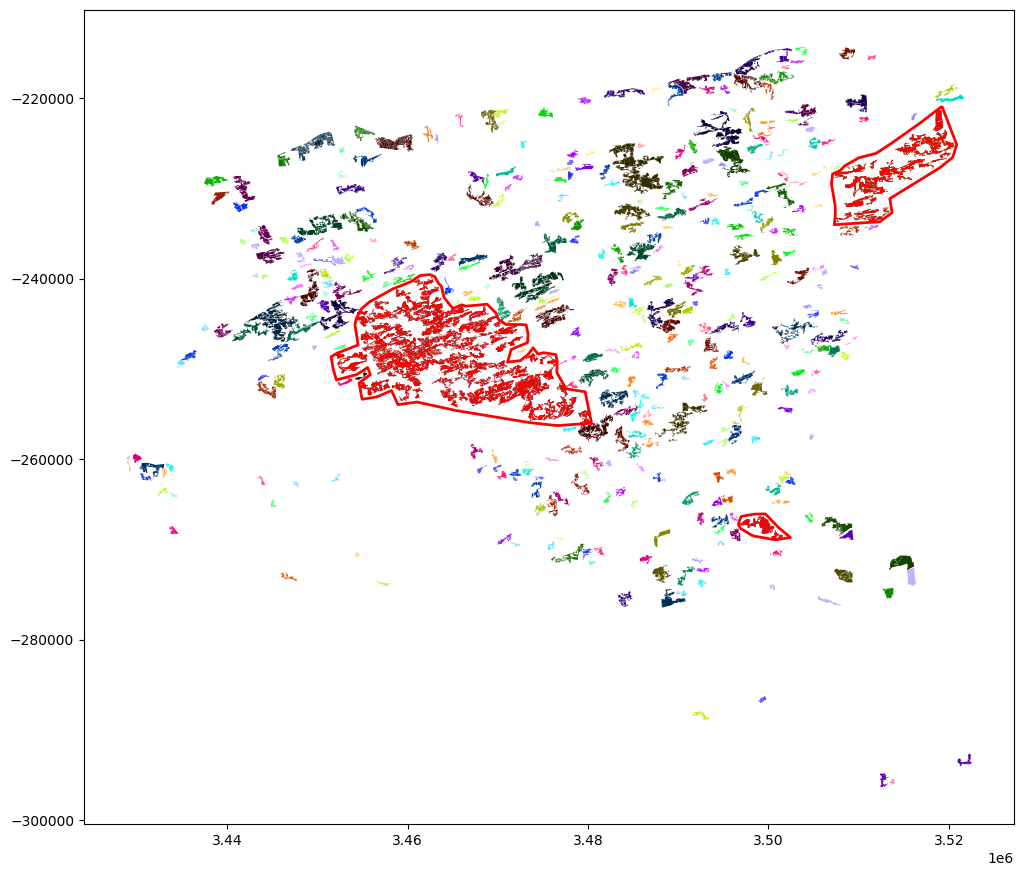

In [ ]:
# ax = gdf_with_cluster_id.plot(
#     column=cluster_id_col,
#     cmap=ListedColormap(
#         generate_colormap(len(gdf_with_cluster_id[cluster_id_col].unique()))
#     ),
#     figsize=(12, 12),
# )
# groups.boundary.plot(ax=ax, color="red", linewidth=2)
# temp_gdf.plot(ax=ax, color="red")

In [ ]:
# # create a mapping from Parcel ID to Group Name
# mapping = {}
# for _, row in temp_gdf.iterrows():
#     parcel_id = row["Parcel ID"]
#     group_name = row["Name"]
#     if parcel_id not in mapping:
#         mapping[parcel_id] = group_name

In [ ]:
# # replace use the mapping to replace parcel IDs inplace
# gdf_with_cluster_id["Parcel ID"] = gdf_with_cluster_id["Parcel ID"].replace(mapping)

## Pivot parcel stats

In [101]:
parcel_gdf = get_aggregate_gdf(
    areas_gdf=gdf_with_cluster_id, cluster_id_col=cluster_id_col
)
parcel_gdf.head()

,Parcel ID,Khasra Count,Khasra ID (Unique),Original Area (ha),Usable Area (ha),Usable and Available Area (ha),Usable but Unavailable Area (ha),Unusable Area (ha),Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area (%),Unusable Area - Settlements (ha),Unusable Area - Water (ha),Unusable Area - Slope (ha),Unusable Area - Slope South 10deg (ha),Unavailable Area - Cropland (ha),Unavailable Area - Isolated Buildings (ha),Building Count,geometry
0,PARCEL_001,184,"27 (BZU4085), 28 (BZU4085), 29 (BZU4085), 30 (...",1052.40,1043.59,956.99,86.60,8.81,99.16,90.93,8.23,0.84,0.84,0.37,7.42,0.18,85.29,5.77,240.0,"POLYGON ((3763379.570 -172233.408, 3762634.632..."
1,PARCEL_002,48,"18 (BZU2375), 23 (BZU2375), 254 (BZU2375), 260...",437.63,436.32,258.21,178.11,1.31,99.70,59.00,40.70,0.30,0.11,1.01,0.18,0.00,174.65,8.99,269.0,"POLYGON ((3769181.461 -218170.070, 3769175.446..."
2,PARCEL_003,24,"48 (BZU2632), 67 (BZU2632), 76 (BZU2632), 1 (B...",363.07,318.10,309.94,8.17,44.97,87.61,85.37,2.25,12.39,0.00,0.00,43.34,1.63,6.19,2.60,63.0,"POLYGON ((3755669.473 -215959.234, 3755502.369..."
3,PARCEL_004,18,"194 (BZU468), 195 (BZU468), 216 (BZU468), 217 ...",326.27,302.26,297.91,4.36,24.01,92.64,91.31,1.34,7.36,0.21,0.00,15.55,8.25,5.40,1.04,66.0,"POLYGON ((3787273.281 -251635.011, 3787271.987..."
4,PARCEL_005,38,"1 (BZU3566), 10 (BZU3566), 180 (BZU3566), 191 ...",277.13,273.00,221.68,51.32,4.13,98.51,79.99,18.52,1.49,0.23,2.61,1.29,0.00,50.01,1.91,73.0,"POLYGON ((3788225.200 -186692.821, 3787940.523..."


## Match to substations

In [102]:
import shapely

In [104]:
substations_gdf = gpd.read_file(PROCESSED_DATA_DIR / "betul_substations.kml").to_crs(
    epsg=INDIA_PROJECTED_CRS
)
# remove z-dimension
substations_gdf.geometry = substations_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)

substations_gdf["Available Margin (MW)"] = (
    substations_gdf["Description"]
    .str.split("Margin ")
    .str[1]
    .str.split("MW")
    .str[0]
    .astype(int)
)
substations_gdf = substations_gdf[["Name", "Available Margin (MW)", "geometry"]]

# filter to those with available margin > 40 (40 not required)
substations_gdf = substations_gdf[substations_gdf["Available Margin (MW)"] > 40]

radius_map = {
    200: 40,
    100: 30,
    50: 20,
}
substations_gdf["Valid Radius (km)"] = substations_gdf["Available Margin (MW)"].map(
    radius_map
)

# buffer substations by their valid radius
substations_gdf["geometry"] = substations_gdf.buffer(
    substations_gdf["Valid Radius (km)"] * 1000
)

In [105]:
substations_gdf

,Name,Available Margin (MW),geometry,Valid Radius (km)
0,BETUL 220,100,"POLYGON ((3809463.176 -225556.789, 3809318.718...",30
1,GUDGAON 220,100,"POLYGON ((3793385.344 -246287.322, 3793240.886...",30
2,MULTAI 132,50,"POLYGON ((3841459.618 -226549.770, 3841363.313...",20
3,BISNOOR 132,50,"POLYGON ((3817160.453 -249535.283, 3817064.148...",20


In [106]:
save_shapefiles(
    substations_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR,
    "substation_coverage_areas",
    formats=["kml"],
)

In [107]:
# add a column to parcel_gdf for each substation, indicating distance from parcel to that substation in meters
for idx, substation_row in substations_gdf.iterrows():
    substation_name = substation_row["Name"]
    substation_geom = substation_row["geometry"].centroid
    parcel_gdf[f"Distance to {substation_name} (km)"] = (
        parcel_gdf.geometry.centroid.distance(substation_geom) / 1000
    ).round(2)

In [108]:
cols = [
    "Distance to BETUL 220 (km)",
    "Distance to GUDGAON 220 (km)",
    "Distance to MULTAI 132 (km)",
    "Distance to BISNOOR 132 (km)",
]
parcel_gdf["Nearest Substation"] = (
    parcel_gdf[cols]
    .idxmin(axis=1)
    .str.replace("Distance to ", "")
    .str.replace(" (km)", "")
)

parcel_gdf["Nearest Substation Distance (km)"] = parcel_gdf[cols].min(axis=1)

In [109]:
save_shapefiles(
    parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)",
    f"Parcels ({distance_threshold}m)",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Layer name 'Parcels (25m)' adjusted to 'Parcels__25m_' for XML validity.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels__25m_.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 1052.4000000000001.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'BETUL 220' of field Parcels__25m_.Distance to MULTAI 132 (km) parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels__25m_.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 437.63.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogri

## Filter parcels to near substation and above 100ha usable

In [111]:
# only keep clusters that overlap a substation buffer
subset_parcel_gdf = parcel_gdf[parcel_gdf.intersects(substations_gdf.unary_union)]
# filter to those with Final Usable Area > 100ha
subset_parcel_gdf = subset_parcel_gdf[subset_parcel_gdf["Usable Area (ha)"] > 100]

save_shapefiles(
    subset_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Filtered",
    "Parcels near substations with >100ha usable",
    formats=["kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Layer name 'Parcels near substations with >100ha usable' adjusted to 'Parcels_near_substations_with__100ha_usable' for XML validity.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels_near_substations_with__100ha_usable.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 437.63.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'BETUL 220' of field Parcels_near_substations_with__100ha_usable.Distance to MULTAI 132 (km) parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels_near_substations_with__100ha_usable.Khasra Count: Lossy conversion occurred when trying to set

In [112]:
# save centroid only version
subset_parcel_centroids_gdf = subset_parcel_gdf.copy()
subset_parcel_centroids_gdf["geometry"] = subset_parcel_centroids_gdf.centroid
save_shapefiles(
    subset_parcel_centroids_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Filtered",
    "Parcels near substations with >100ha usable (centroids)",
    formats=["kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Layer name 'Parcels near substations with >100ha usable (centroids)' adjusted to 'Parcels_near_substations_with__100ha_usable__centroids_' for XML validity.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels_near_substations_with__100ha_usable__centroids_.Khasra Count: Lossy conversion occurred when trying to set 64 bit integer field from real value 437.63.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'BETUL 220' of field Parcels_near_substations_with__100ha_usable__centroids_.Distance to MULTAI 132 (km) parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Parcels_near_substations_with__100ha_usable__centroids

In [113]:
chosen_parcel_ids = subset_parcel_gdf[cluster_id_col].unique()

subset_gdf_with_cluster_id = gdf_with_cluster_id[
    gdf_with_cluster_id[cluster_id_col].isin(chosen_parcel_ids)
]
subset_gdf_with_cluster_id.sort_values(by=[cluster_id_col, "Khasra ID"], inplace=True)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_59822/4154532285.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_gdf_with_cluster_id.sort_values(by=[cluster_id_col, "Khasra ID"], inplace=True)


In [114]:
save_shapefiles(
    subset_gdf_with_cluster_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_final_selection",
    formats=["csv", "kml"],
)